In [ ]:
# ==========================================
# 0. import libraries
# ==========================================
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore') # 忽略所有警告信息

# pipreqsnb ./ --force --encoding=utf-8 使用此行代码来实现到处requirements.txt文件，方便在其他环境中安装依赖包


In [ ]:
# ==========================================
# 1.Load Packages and Data
# ==========================================
print("1. Read data and clean it...")
# parquet 读取，速度极快！
df = pd.read_parquet('data/USstocks.parquet')

# 强制转换为数值型（防御性编程，防止原数据中有字符串形式的数字）
df['ri'] = pd.to_numeric(df['ri'], errors='coerce')
df['rm'] = pd.to_numeric(df['rm'], errors='coerce')
df['rf'] = pd.to_numeric(df['rf'], errors='coerce')

# 计算超额收益率 (Excess Returns)
df['ri_e'] = df['ri'] - df['rf']
df['rm_e'] = df['rm'] - df['rf']

# 构建日期列 (将 year 和 month 合并为 datetime 格式)
df['date'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month'].astype(str) + '-01')

# 过滤缺失值，并按股票代码 (permno) 和日期 (date) 排序
df_clean = df.dropna(subset=['ri_e', 'rm_e']).sort_values(by=['permno', 'date'])
print(f"--> Data cleaning complete! There are {len(df_clean)} valid observations.")


# ==========================================
# 2. Estimate 36-month rolling Beta and construct 10 portfolios
# ==========================================
print("\n2. Computing Beta and constructing 10 portfolios...")
print("(This part requires looping through hundreds of months and calculating covariance, please be patient for a few seconds)")

all_dates = sorted(df_clean['date'].unique())
portfolio_returns_list = []

# 从第36个月开始循环 (索引为35)
for i in range(35, len(all_dates)):
    current_date = all_dates[i]
    start_date = all_dates[i - 35]
    
    # 截取过去 36 个月的窗口数据
    window_data = df_clean[(df_clean['date'] >= start_date) & (df_clean['date'] <= current_date)]
    
    # 定义一个内部函数来计算每家公司的 Beta (要求至少 18 个有效观测值)
    def calc_beta(group):
        if len(group) >= 18:
            cov_matrix = np.cov(group['ri_e'], group['rm_e'])
            return cov_matrix[0, 1] / cov_matrix[1, 1]
        return np.nan

    # 分组计算 Beta
    betas_t = window_data.groupby('permno').apply(calc_beta).reset_index(name='beta')
    betas_t = betas_t.dropna(subset=['beta'])
    
    if betas_t.empty:
        continue
        
    # 按照 Beta 值大小，将公司划分为 10 个十分位投资组合 (deciles)
    betas_t['portfolio'] = pd.qcut(betas_t['beta'].rank(method='first'), 10, labels=False) + 1
    
    # 获取当月的实际超额收益率
    current_month_returns = df_clean[df_clean['date'] == current_date][['permno', 'date', 'ri_e', 'rm_e']]
    port_ret_t = pd.merge(current_month_returns, betas_t, on='permno')
    
    # 计算每个投资组合的等权重平均收益率和平均 Beta
    port_summary = port_ret_t.groupby(['date', 'portfolio']).agg(
        R_p_e=('ri_e', 'mean'),
        R_m_e=('rm_e', 'first'),
        beta_p=('beta', 'mean')
    ).reset_index()
    
    portfolio_returns_list.append(port_summary)

# 将所有列表合并为一个大的面板数据集 (Panel Data)
df_portfolio_panel = pd.concat(portfolio_returns_list, ignore_index=True)
df_portfolio_panel = df_portfolio_panel.sort_values(['portfolio', 'date'])

print("--> Panel data `df_portfolio_panel` is ready.")


In [ ]:
# ==========================================
# 1.1.1 Time-series CAPM tests
# ==========================================
print("Beginning 1.1.1 Time-series CAPM tests (with Newey-West lag=4 adjustment)...")

ts_results_list = []

# 按 10 个投资组合分组进行 OLS 回归
for port, group in df_portfolio_panel.groupby('portfolio'):
    Y = group['R_p_e']  # 组合超额收益
    X = sm.add_constant(group['R_m_e'])  # 市场超额收益（自动添加截距项 Alpha）
    
    # 核心：cov_type='HAC' 和 maxlags=4 完美替代了 R 中的 NeweyWest(lag=4)
    model = sm.OLS(Y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
    
    ts_results_list.append({
        'portfolio': port,
        'alpha': model.params.iloc[0],
        'alpha_tstat': model.tvalues.iloc[0],
        'beta': model.params.iloc[1],
        'beta_tstat': model.tvalues.iloc[1],
        'r_squared': model.rsquared,
        'model_obj': model  # 偷偷保留完整的模型对象，因为接下来的 GRS 检验需要用它的残差
    })

# 转换为 DataFrame 方便展示
ts_results = pd.DataFrame(ts_results_list)

print("\n--- 1.1.1 Regression results of portfolio ---")
# 打印时隐藏 model_obj 列，并保留 4 位小数，保持排版美观
display_cols = ['portfolio', 'alpha', 'alpha_tstat', 'beta', 'beta_tstat', 'r_squared']
print(ts_results[display_cols].round(4).to_string(index=False))


# ==========================================
# 1.1.2 Gibbons-Ross-Shanken Test
# ==========================================
print("\n" + "="*42)
print("Beginning 1.1.2 GRS Test...")

# 1. 构建投资组合超额收益矩阵 (T x N)
ret_mat = df_portfolio_panel.pivot(index='date', columns='portfolio', values='R_p_e').values

# 2. 构建市场因子矩阵 (T x 1)
factor_mat = df_portfolio_panel[['date', 'R_m_e']].drop_duplicates().sort_values('date')['R_m_e'].values

T_obs = factor_mat.shape[0]  # 时间总期数 T
N_port = ret_mat.shape[1]    # 资产组合数量 N (10组)
K_factor = 1                 # 因子数量 K (这里只有 RM_e 1 个)

# 3. 提取 alpha 向量 (N x 1) 和残差矩阵 (T x N)
alpha_vec = ts_results['alpha'].values.reshape(-1, 1)
residuals_mat = np.column_stack([res['model_obj'].resid for res in ts_results_list])

# 4. 计算残差的协方差矩阵 Sigma_hat
Sigma_hat = (residuals_mat.T @ residuals_mat) / (T_obs - K_factor - 1)

# 5. 计算市场因子的样本均值和方差
f_bar = factor_mat.mean()
Omega_f = factor_mat.var(ddof=1)

# 6. 计算 GRS 统计量的三大项 (对应你 R 代码里的 term1, term2, term3)
term1 = (T_obs - N_port - K_factor) / N_port
term2 = alpha_vec.T @ np.linalg.inv(Sigma_hat) @ alpha_vec
term3 = 1 / (1 + (f_bar**2 / Omega_f))

GRS_stat = float(term1 * term2 * term3)

# 7. 计算 P-value (服从 F 分布)
p_val = 1 - stats.f.cdf(GRS_stat, N_port, T_obs - N_port - K_factor)

print("\n--- 1.1.2 GRS Test Result ---")
print(f"GRS F-statistic: {GRS_stat:.4f}")
print(f"P-value:         {p_val:.6e}")

# Conclusion based on P-value
if p_val < 0.05:
    print("\n Conclusion: P-value < 0.05, Refuse H0 (joint Alpha = 0)。")
    print("Which means Beta can not explain the all riskys. There is abnormal returns in the market. CAPM is not supported.")
else:
    print("\n Conclusion: Cannot reject H0. CAPM is supported.")


Beginning 1.2.1 Fama-MacBeth Cross-sectional regressions...

--- 1.2.1 Fama-MacBeth Test Results ---
                  Term   Mean  t-Statistic  P-Value
   Gamma_0 (Intercept) 0.0784       0.7212   0.4712
Gamma_1 (Risk Premium) 0.1884       1.0324   0.3025

 Conclusion: Risk premium Gamma_1 P Value > 0.05, Cannot reject H0 (Gamma_1 = 0)。
This reveals the failure of CAPM: High beta does not bring significantly higher returns.

Beginning 1.2.2 Plotting Average Portfolio Excess Return vs. Beta and SML...


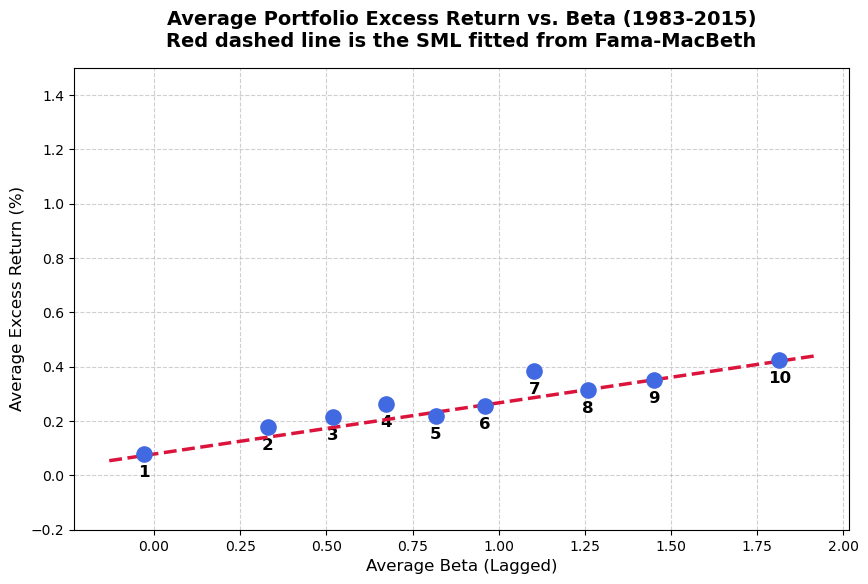

In [9]:
# ==========================================
# 1.2.1 Fama-MacBeth Cross-sectional regressions
# ==========================================
print("Beginning 1.2.1 Fama-MacBeth Cross-sectional regressions...")

# 1. 生成滞后一期的 Beta
# 注意：我们要按投资组合 分组进行滞后
df_portfolio_panel['beta_p_lag'] = df_portfolio_panel.groupby('portfolio')['beta_p'].shift(1)

# 删除因为滞后而产生的第一期 NaN 缺失值
fm_data = df_portfolio_panel.dropna(subset=['beta_p_lag']).copy()

fm_regressions_list = []

# 2. 跨期回归 (Cross-sectional regressions)：每个月跑一次截面 OLS
for date, group in fm_data.groupby('date'):
    Y = group['R_p_e']
    X = sm.add_constant(group['beta_p_lag'])
    
    # 每月的横截面回归
    model = sm.OLS(Y, X).fit()
    
    fm_regressions_list.append({
        'date': date,
        'Gamma_0 (Intercept)': model.params.iloc[0],
        'Gamma_1 (Risk Premium)': model.params.iloc[1]
    })

df_fm_regs = pd.DataFrame(fm_regressions_list)

# 3. 计算 Gamma_0 和 Gamma_1 的时间序列均值、t 统计量和 p 值
fm_results_list = []
for term in ['Gamma_0 (Intercept)', 'Gamma_1 (Risk Premium)']:
    estimates = df_fm_regs[term]
    
    gamma_mean = estimates.mean()
    gamma_sd = estimates.std(ddof=1) # 样本标准差
    n_months = len(estimates)
    
    # 计算 t-stat 和双侧 p-value
    t_stat = gamma_mean / (gamma_sd / np.sqrt(n_months))
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=n_months - 1))
    
    fm_results_list.append({
        'Term': term,
        'Mean': gamma_mean,
        't-Statistic': t_stat,
        'P-Value': p_value
    })

df_fm_results = pd.DataFrame(fm_results_list)

print("\n--- 1.2.1 Fama-MacBeth Test Results ---")
print(df_fm_results.round(4).to_string(index=False))

p_val_gamma1 = df_fm_results.loc[1, 'P-Value']
if p_val_gamma1 > 0.05:
    print("\n Conclusion: Risk premium Gamma_1 P Value > 0.05, Cannot reject H0 (Gamma_1 = 0)。")
    print("This reveals the failure of CAPM: High beta does not bring significantly higher returns.")


# ==========================================
# 1.2.2 Plotting Average Portfolio Excess Return vs. Beta and SML
# ==========================================
print("\n" + "="*42)
print("Beginning 1.2.2 Plotting Average Portfolio Excess Return vs. Beta and SML...")

# 计算每个投资组合的时间序列平均超额收益和平均 Beta
portfolio_summary = fm_data.groupby('portfolio').agg(
    mean_R_p_e=('R_p_e', 'mean'),
    mean_beta=('beta_p_lag', 'mean')
).reset_index()

# 提取上面回归算出来的平均 Gamma_0 (截距) 和 Gamma_1 (斜率)
gamma_0_mean = df_fm_results.loc[0, 'Mean']
gamma_1_mean = df_fm_results.loc[1, 'Mean']

# 开始绘图 (替代 R 的 ggplot2)
plt.figure(figsize=(10, 6))

# 画散点 (10个组合)
plt.scatter(portfolio_summary['mean_beta'], portfolio_summary['mean_R_p_e'], 
            color='royalblue', s=120, zorder=5)

# 给每个点打上 1-10 的标签
for i, row in portfolio_summary.iterrows():
    plt.text(row['mean_beta'], row['mean_R_p_e'] - 0.04, str(int(row['portfolio'])), 
             ha='center', va='top', fontweight='bold', fontsize=12)

# 画 SML 拟合线
x_vals = np.array([portfolio_summary['mean_beta'].min() - 0.1, portfolio_summary['mean_beta'].max() + 0.1])
y_vals = gamma_0_mean + gamma_1_mean * x_vals
plt.plot(x_vals, y_vals, color='crimson', linestyle='dashed', linewidth=2.5, zorder=4)

# 图表美化
plt.ylim(-0.2, 1.5)
plt.title("Average Portfolio Excess Return vs. Beta (1983-2015)\nRed dashed line is the SML fitted from Fama-MacBeth", 
          fontweight='bold', fontsize=14, pad=15)
plt.xlabel("Average Beta (Lagged)", fontsize=12)
plt.ylabel("Average Excess Return (%)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# 显示图表
plt.show()

In [12]:
# ==========================================
# 1.3 Sub-sample Stability
# ==========================================
print("Beginning 1.3  (Era I vs Era II)...\n")

# 定义两个子时期的时间边界
era1_end = pd.to_datetime("1999-12-31")
era2_start = pd.to_datetime("2000-01-01")

# ==========================================
# 辅助函数 1：时间序列 CAPM 回归 (带 Newey-West)
# ==========================================
def run_ts_capm(data):
    results = []
    for port, group in data.groupby('portfolio'):
        Y = group['R_p_e']
        X = sm.add_constant(group['R_m_e'])
        model = sm.OLS(Y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
        results.append({
            'portfolio': port,
            'alpha': model.params.iloc[0],
            'alpha_tstat': model.tvalues.iloc[0],
            'beta': model.params.iloc[1]
        })
    return pd.DataFrame(results).round(4)

# ==========================================
# 辅助函数 2：Fama-MacBeth 跨期回归
# ==========================================
def run_fm_capm(data):
    regs = []
    # 每月横截面回归
    for date, group in data.groupby('date'):
        Y = group['R_p_e']
        X = sm.add_constant(group['beta_p_lag'])
        model = sm.OLS(Y, X).fit()
        regs.append({
            'Gamma_0': model.params.iloc[0],
            'Gamma_1': model.params.iloc[1]
        })
        
    df_regs = pd.DataFrame(regs)
    
    # 计算时间序列均值和 t 检验
    results = []
    for term in ['Gamma_0', 'Gamma_1']:
        mean_val = df_regs[term].mean()
        sd_val = df_regs[term].std(ddof=1)
        n_months = len(df_regs)
        t_stat = mean_val / (sd_val / np.sqrt(n_months))
        p_val = 2 * (1 - stats.t.cdf(abs(t_stat), df=n_months - 1))
        
        results.append({
            'Term': term, 
            'Mean': mean_val, 
            't-Stat': t_stat, 
            'P-Value': p_val
        })
    return pd.DataFrame(results).round(4)

# ==========================================
# 划分数据并执行检验 (复现 R 中的 filter)
# ==========================================
# 1. 切分时间序列数据
era1_ts_data = df_portfolio_panel[df_portfolio_panel['date'] <= era1_end]
era2_ts_data = df_portfolio_panel[df_portfolio_panel['date'] >= era2_start]

# 2. 切分 Fama-MacBeth 数据 (使用上一步生成的去除了缺失值的 fm_data)
era1_fm_data = fm_data[fm_data['date'] <= era1_end]
era2_fm_data = fm_data[fm_data['date'] >= era2_start]

print("="*45)
print("--- 1.3.a Era I (1983-1999) Time-Series Result ---")
print(run_ts_capm(era1_ts_data).to_string(index=False))

print("\n--- 1.3.a Era II (2000-2015) Time-Series Result ---")
print(run_ts_capm(era2_ts_data).to_string(index=False))

print("\n" + "="*45)
print("--- 1.3.b Era I (1983-1999) Fama-MacBeth Result ---")
print(run_fm_capm(era1_fm_data).to_string(index=False))

print("\n--- 1.3.b Era II (2000-2015) Fama-MacBeth Result ---")
print(run_fm_capm(era2_fm_data).to_string(index=False))


Beginning 1.3  (Era I vs Era II)...

--- 1.3.a Era I (1983-1999) Time-Series Result ---
 portfolio   alpha  alpha_tstat    beta
         1 -0.1399      -0.6147 -0.0858
         2 -0.3473      -1.7080  0.3078
         3 -0.4301      -2.0007  0.4503
         4 -0.4837      -2.5484  0.5910
         5 -0.6228      -3.2878  0.7383
         6 -0.6376      -3.2248  0.8593
         7 -0.5694      -2.9418  0.9605
         8 -0.7769      -4.2030  1.1533
         9 -0.8209      -4.3379  1.2975
        10 -0.8502      -4.2074  1.6143

--- 1.3.a Era II (2000-2015) Time-Series Result ---
 portfolio   alpha  alpha_tstat   beta
         1  0.3607       1.9928 0.0766
         2  0.3132       1.9403 0.3713
         3  0.2530       1.6681 0.5670
         4  0.2207       1.4154 0.7177
         5  0.0806       0.5188 0.8694
         6  0.0172       0.1005 0.9792
         7  0.0407       0.2417 1.1476
         8 -0.1275      -0.6947 1.3309
         9 -0.1906      -1.0795 1.4692
        10 -0.4550      -2.19

Unconditional parameter of CAPM not only has poor performance in the whole sample, but also become unstable in the time-varying.